In [244]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.feature_extraction.text import CountVectorizer
from textblob import TextBlob
import scipy.stats as stats
import gensim
from gensim import corpora, models
from nltk.corpus import stopwords
from collections import Counter
import folium
from folium import plugins
from IPython.display import HTML
import warnings
warnings.filterwarnings('ignore')

In [245]:
df = pd.read_csv("/home/artur/Desktop/Food_Inspections.csv")


In [246]:
df.rename(columns={"License #": "license"}, inplace=True)
df['year'] = pd.DatetimeIndex(df['Inspection Date']).year
df['month'] = pd.DatetimeIndex(df['Inspection Date']).month
df['day'] = pd.DatetimeIndex(df['Inspection Date']).day

df.head()

,Inspection ID,DBA Name,AKA Name,license,Facility Type,Risk,Address,City,State,Zip,Inspection Date,Inspection Type,Results,Violations,Latitude,Longitude,Location,year,month,day
0,2587265,AREPA GEORGE,AREPA GEORGE,2522680.0,Restaurant,Risk 1 (High),1552 N KEDZIE AVE,CHICAGO,IL,60651.0,12/20/2023,Canvass Re-Inspection,Pass,NaN,41.909898,-87.707145,"(41.909897849174, -87.70714515263228)",2023,12,20
1,2587168,MARGARITA'S PIZZERIA,MARGARITA'S PIZZERIA,48819.0,Restaurant,Risk 1 (High),2705 - 2707 E 79TH ST,CHICAGO,IL,60649.0,12/19/2023,Complaint Re-Inspection,Pass,NaN,41.751723,-87.558700,"(41.75172337100072, -87.55869963532268)",2023,12,19
2,2587169,BRISTOL FOOD & LIQUOR,BRISTOL FOOD & LIQUOR,2943885.0,Grocery Store,Risk 3 (Low),5201-5207 W BELMONT AVE,CHICAGO,IL,60641.0,12/19/2023,License,Pass,NaN,41.938589,-87.756810,"(41.93858918622007, -87.75681004516909)",2023,12,19
3,2587086,FARMAIR'S MARKET,FARMER'S MARKET (T5 / M7),2944236.0,Grocery Store,Risk 3 (Low),11601 W TOUHY AVE,CHICAGO,IL,60666.0,12/18/2023,License,Pass,NaN,42.008536,-87.914428,"(42.008536400868735, -87.91442843927047)",2023,12,18
4,2587088,URBAN LUXE CAFE INC.,URBAN LUXE CAFE INC.,2917499.0,Restaurant,Risk 2 (Medium),2911 E 79TH ST,CHICAGO,IL,60649.0,12/18/2023,License,Pass,47. FOOD & NON-FOOD CONTACT SURFACES CLEANABLE...,41.751791,-87.553571,"(41.751791151661955, -87.55357107463779)",2023,12,18


In [247]:
# df = df[df['Inspection Type'].notna()]
# df = df[df['Inspection Type']=='Canvass']
df.dtypes


Inspection ID        int64
DBA Name            object
AKA Name            object
license            float64
Facility Type       object
Risk                object
Address             object
City                object
State               object
Zip                float64
Inspection Date     object
Inspection Type     object
Results             object
Violations          object
Latitude           float64
Longitude          float64
Location            object
year                 int32
month                int32
day                  int32
dtype: object

In [248]:
df.dropna(subset=["Inspection Date", "license", "Latitude", "Longitude"], inplace=True)
df = df[~df.Results.isin(["Out of Business", "Business Not Located", "No Entry", "Not Ready"])]
len(set(df['DBA Name'].tolist()))
df['DBA Name'].value_counts()[:10]

DBA Name
SUBWAY                          3259
DUNKIN DONUTS                   1721
MCDONALD'S                       697
7-ELEVEN                         472
CHIPOTLE MEXICAN GRILL           411
MCDONALDS                        364
POTBELLY SANDWICH WORKS LLC      348
POTBELLY SANDWICH WORKS          314
DUNKIN DONUTS/BASKIN ROBBINS     298
CORNER BAKERY CAFE               284
Name: count, dtype: int64

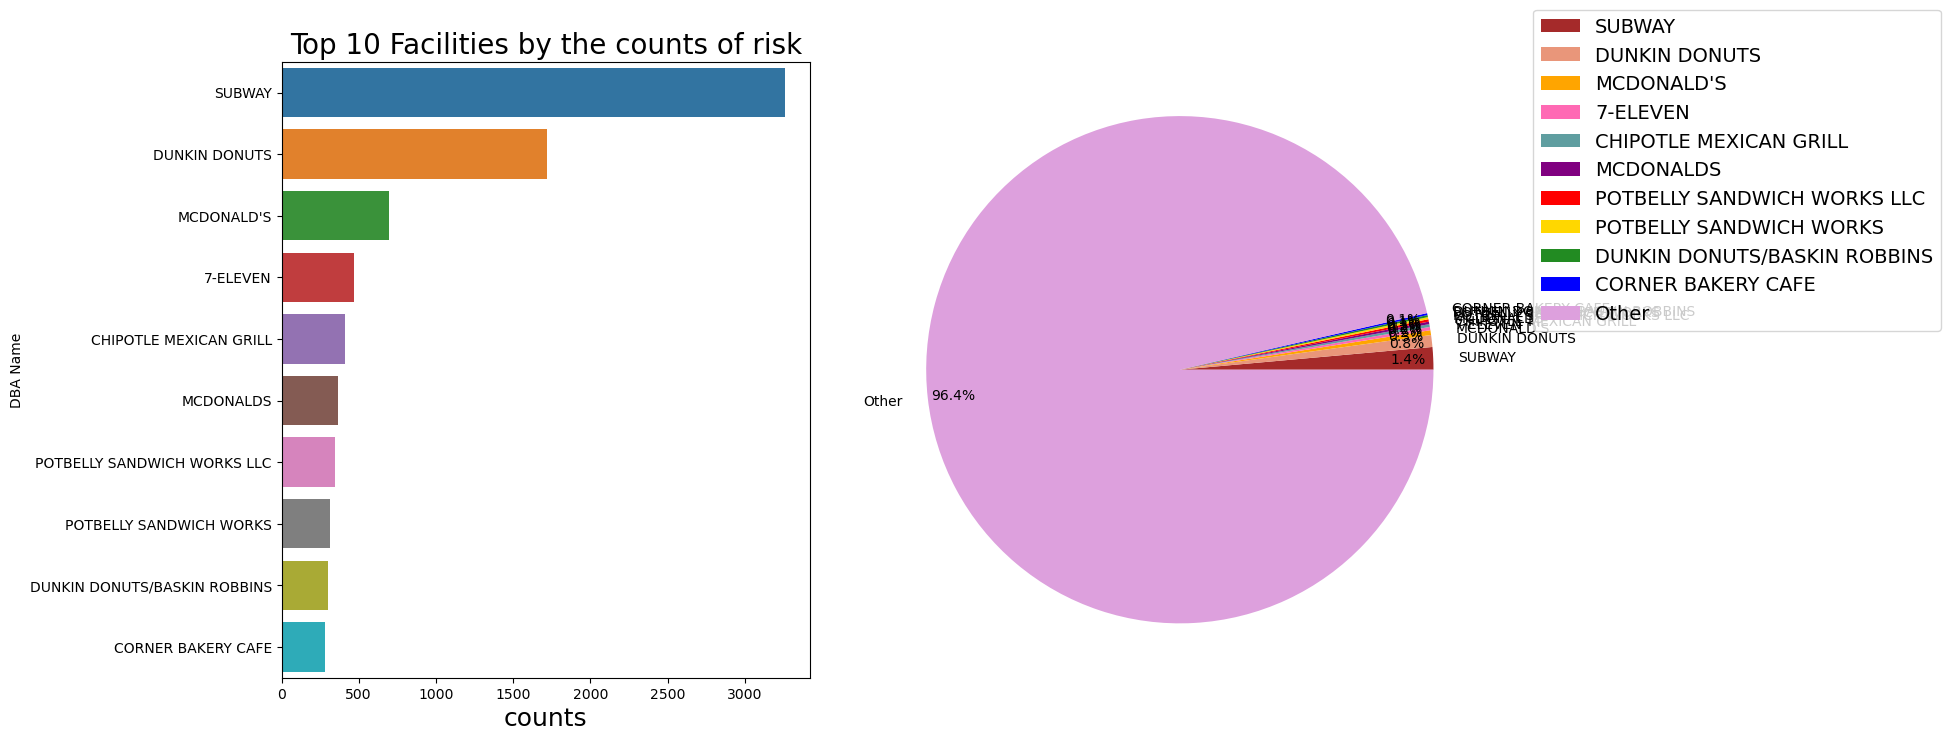

In [249]:
data_risk1=df
fig,ax=plt.subplots(1,2,figsize=(15,8))
sns.barplot(x=data_risk1['DBA Name'].value_counts()[:10],y=data_risk1['DBA Name'].value_counts()[:10].index,ax=ax[0])
ax[0].set_title("Top 10 Facilities by the counts of risk",size=20)
ax[0].set_xlabel('counts',size=18)

count=data_risk1.groupby(['DBA Name'])['Inspection ID'].agg('count').sort_values(ascending=False)
groups=list(data_risk1.groupby(['DBA Name'])['Inspection ID'].agg('count').sort_values(ascending=False).index[:10])
counts=list(count[:10])
counts.append(count.agg(sum)-count[:10].agg('sum'))
groups.append('Other')
type_dict=pd.DataFrame({"group":groups,"counts":counts})
clr1=('brown','darksalmon','orange','hotpink','cadetblue','purple','red','gold','forestgreen','blue','plum')
type_dict.plot(kind='pie', y='counts', labels=groups,colors=clr1,autopct='%1.1f%%', pctdistance=0.9, radius=1.2,ax=ax[1])
ax[1].set_ylabel('')
ax[1].legend(loc=0, ncol=1, fontsize=14,bbox_to_anchor=(1.15,1.2))

Text(0, 0.5, 'LATITUDE')

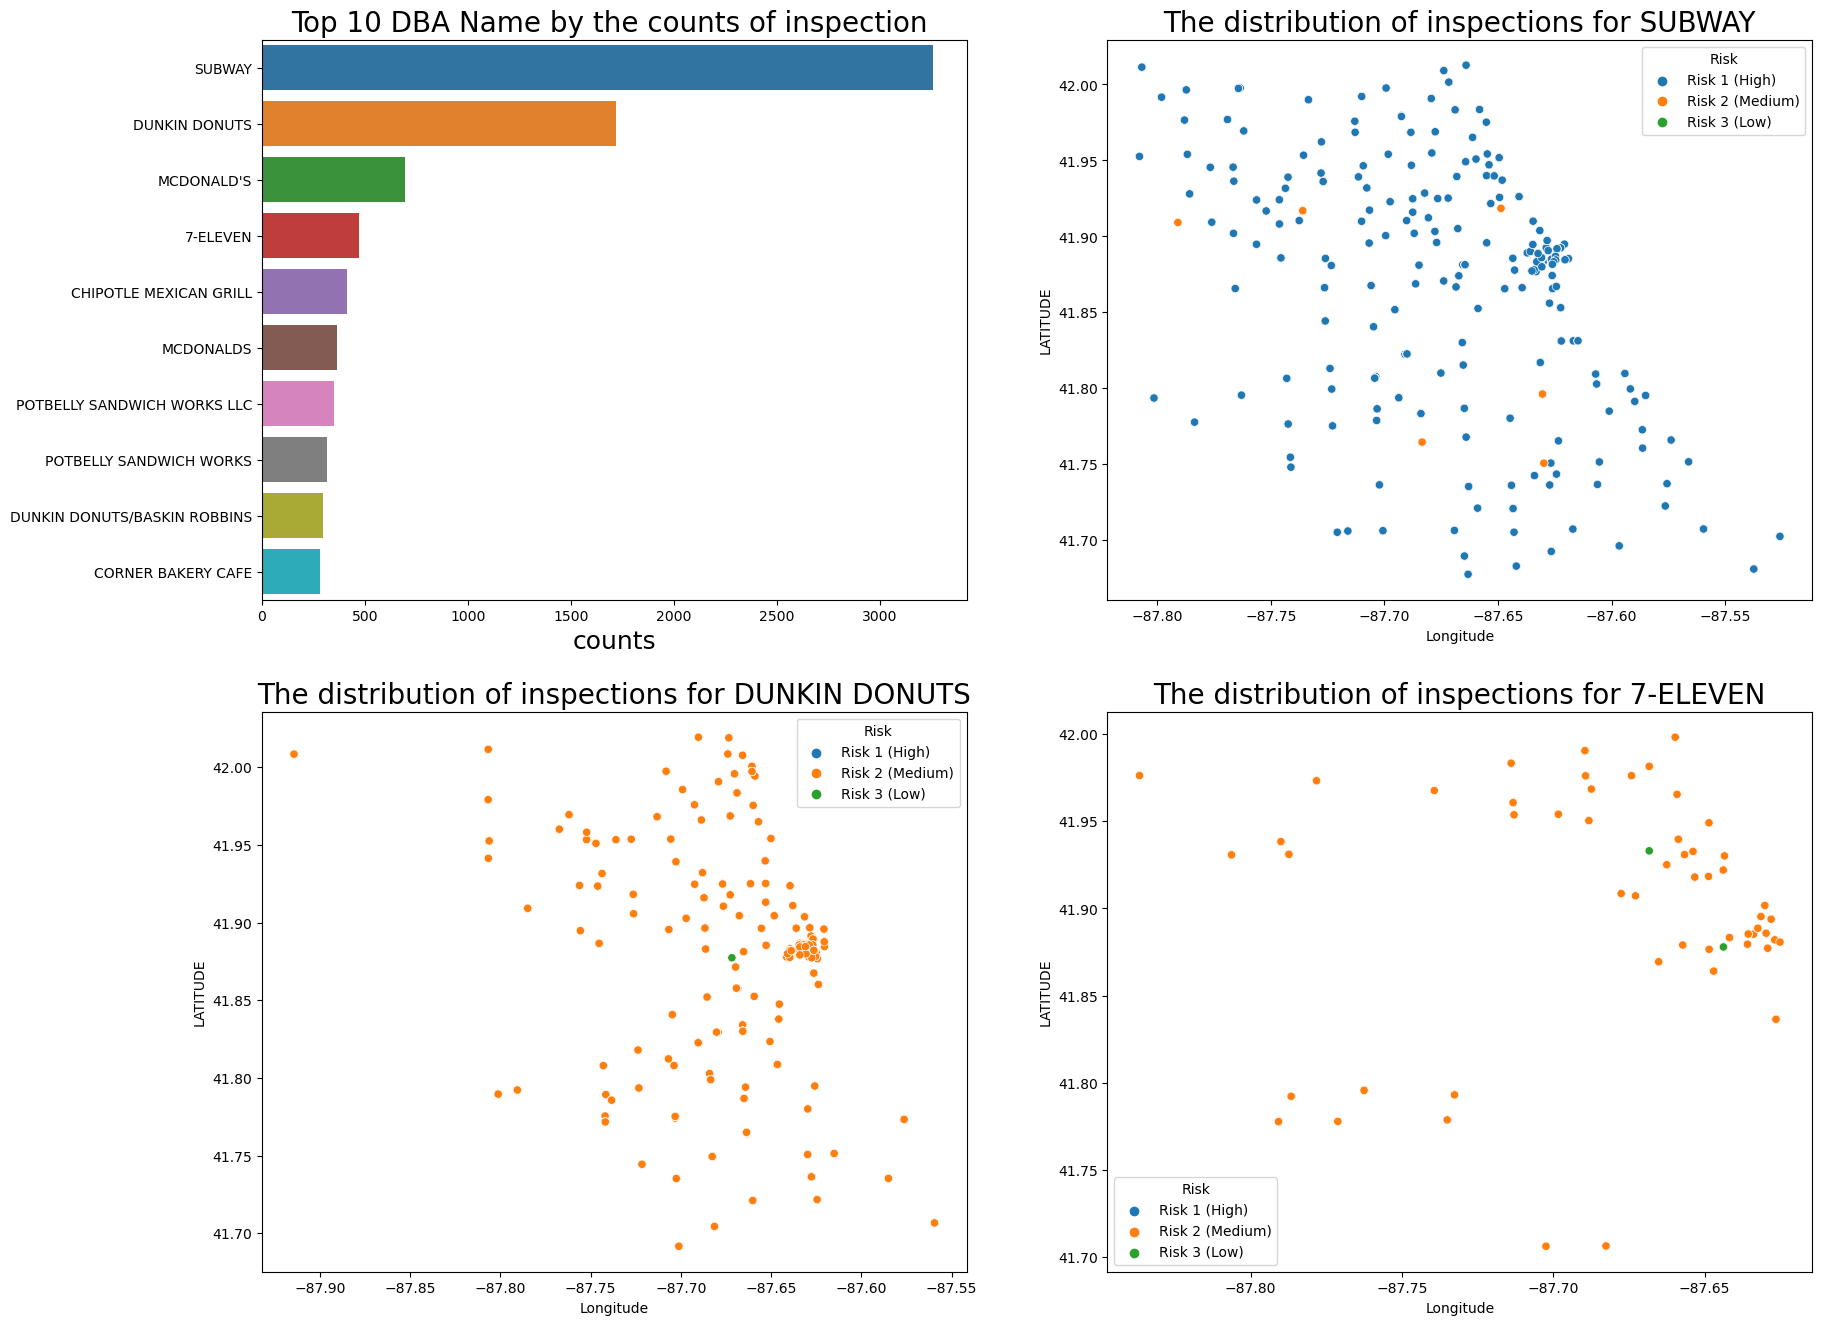

In [250]:
fig,ax=plt.subplots(2,2,figsize=(20,16))
y=df['DBA Name'].value_counts()[:10].index
x=df['DBA Name'].value_counts()[:10]
sns.barplot(x=x,y=y,ax=ax[0,0])
ax[0,0].set_title("Top 10 DBA Name by the counts of inspection ",size=20)
ax[0,0].set_xlabel('counts',size=18)
ax[0,0].set_ylabel('')

sns.scatterplot(x='Longitude',y='Latitude',hue='Risk',hue_order=['Risk 1 (High)','Risk 2 (Medium)','Risk 3 (Low)'] ,data=df[df['DBA Name']=='SUBWAY'], ax=ax[0,1])
ax[0,1].set_title("The distribution of inspections for SUBWAY",size=20)
ax[0,1].set_xlabel('Longitude')
ax[0,1].set_ylabel('LATITUDE')

sns.scatterplot(x='Longitude',y='Latitude',hue='Risk' ,hue_order=['Risk 1 (High)','Risk 2 (Medium)','Risk 3 (Low)'],data=df[df['DBA Name']=='DUNKIN DONUTS'], ax=ax[1,0])
ax[1,0].set_title("The distribution of inspections for DUNKIN DONUTS",size=20)
ax[1,0].set_xlabel('Longitude')
ax[1,0].set_ylabel('LATITUDE')

sns.scatterplot(x='Longitude',y='Latitude',hue='Risk',hue_order=['Risk 1 (High)','Risk 2 (Medium)','Risk 3 (Low)'] ,data=df[df['DBA Name']=='7-ELEVEN'], ax=ax[1,1])
ax[1,1].set_title("The distribution of inspections for 7-ELEVEN",size=20)
ax[1,1].set_xlabel('Longitude')
ax[1,1].set_ylabel('LATITUDE')

In [251]:
len(set(df['license'].tolist()))


38915

In [252]:
len(set(df['Facility Type'].tolist()))


491

In [253]:
import plotly.graph_objs as go
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot

# Assuming df is your DataFrame
x = df['Facility Type'].value_counts().index.values.astype('str')[:10]
y = df['Facility Type'].value_counts().values[:10]
pct = [("%.2f"%(v*100))+"%" for v in (y/len(df))][:10]

trace1 = go.Bar(x=x, y=y, text=pct)
layout = dict(title= 'Number of Facility Type',
              yaxis = dict(title='Count'),
              xaxis = dict(title='Facility Type'))
fig = dict(data=[trace1], layout=layout)
iplot(fig)


Text(0, 0.5, 'LATITUDE')

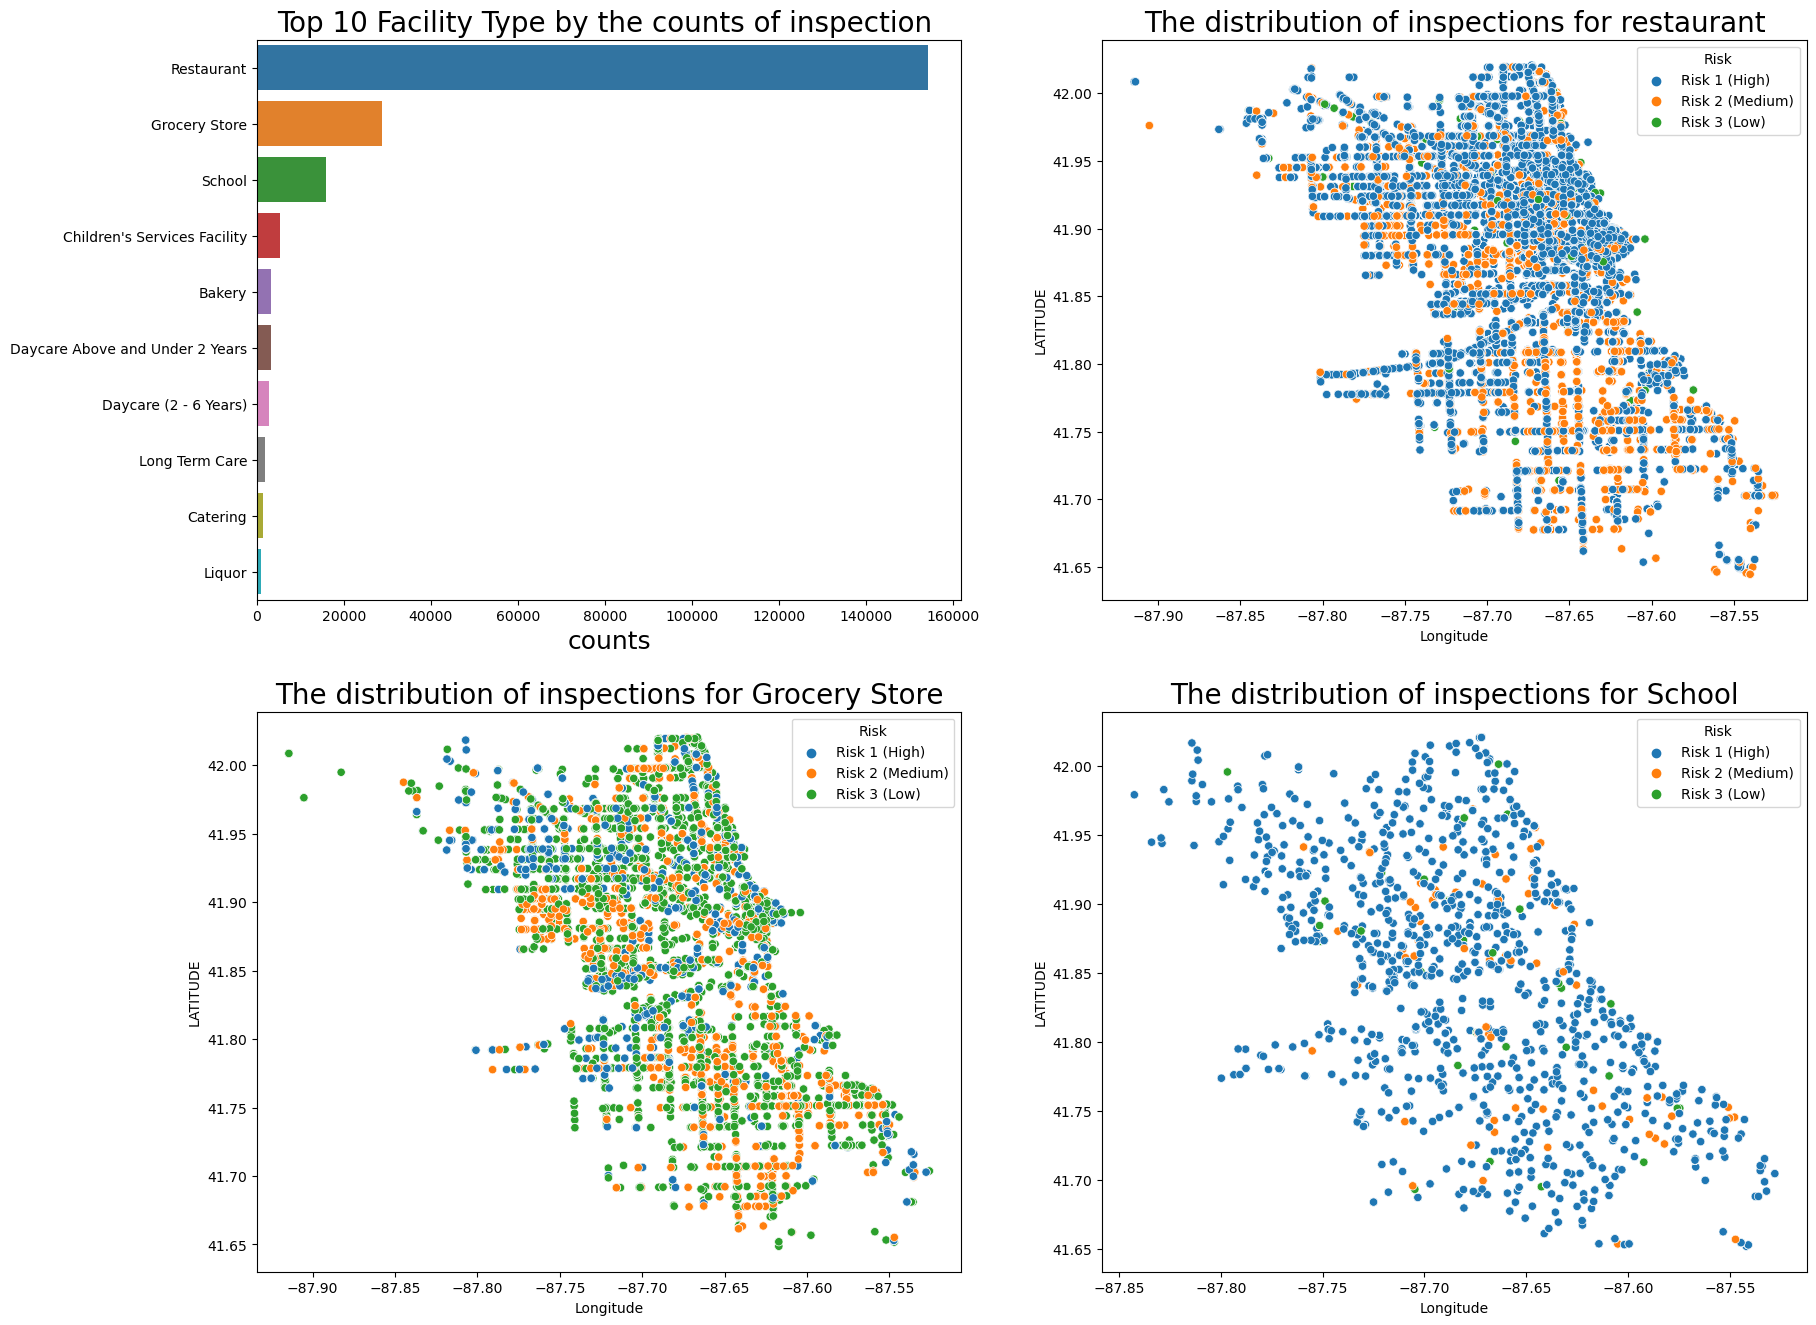

In [254]:
fig,ax=plt.subplots(2,2,figsize=(20,16))
y=df['Facility Type'].value_counts()[:10].index
x=df['Facility Type'].value_counts()[:10]
sns.barplot(x=x,y=y,ax=ax[0,0])
ax[0,0].set_title("Top 10 Facility Type by the counts of inspection ",size=20)
ax[0,0].set_xlabel('counts',size=18)
ax[0,0].set_ylabel('')

sns.scatterplot(x='Longitude',y='Latitude',hue='Risk',hue_order=['Risk 1 (High)','Risk 2 (Medium)','Risk 3 (Low)'] ,data=df[df['Facility Type']=='Restaurant'], ax=ax[0,1])
ax[0,1].set_title("The distribution of inspections for restaurant",size=20)
ax[0,1].set_xlabel('Longitude')
ax[0,1].set_ylabel('LATITUDE')

sns.scatterplot(x='Longitude',y='Latitude',hue='Risk' ,hue_order=['Risk 1 (High)','Risk 2 (Medium)','Risk 3 (Low)'],data=df[df['Facility Type']=='Grocery Store'], ax=ax[1,0])
ax[1,0].set_title("The distribution of inspections for Grocery Store",size=20)
ax[1,0].set_xlabel('Longitude')
ax[1,0].set_ylabel('LATITUDE')

sns.scatterplot(x='Longitude',y='Latitude',hue='Risk',hue_order=['Risk 1 (High)','Risk 2 (Medium)','Risk 3 (Low)'] ,data=df[df['Facility Type']=='School'], ax=ax[1,1])
ax[1,1].set_title("The distribution of inspections for School",size=20)
ax[1,1].set_xlabel('Longitude')
ax[1,1].set_ylabel('LATITUDE')

In [255]:
x = df['Risk'].value_counts().index.values.astype('str')
y = df['Risk'].value_counts().values
pct = [("%.2f"%(v*100))+"%"for v in (y/len(df))]


trace1 = go.Bar(x=x, y=y, text=pct)
layout = dict(title= 'Type of Risk Count',
              yaxis = dict(title='Count'),
              xaxis = dict(title='Risk'))
fig=dict(data=[trace1], layout=layout)
iplot(fig)

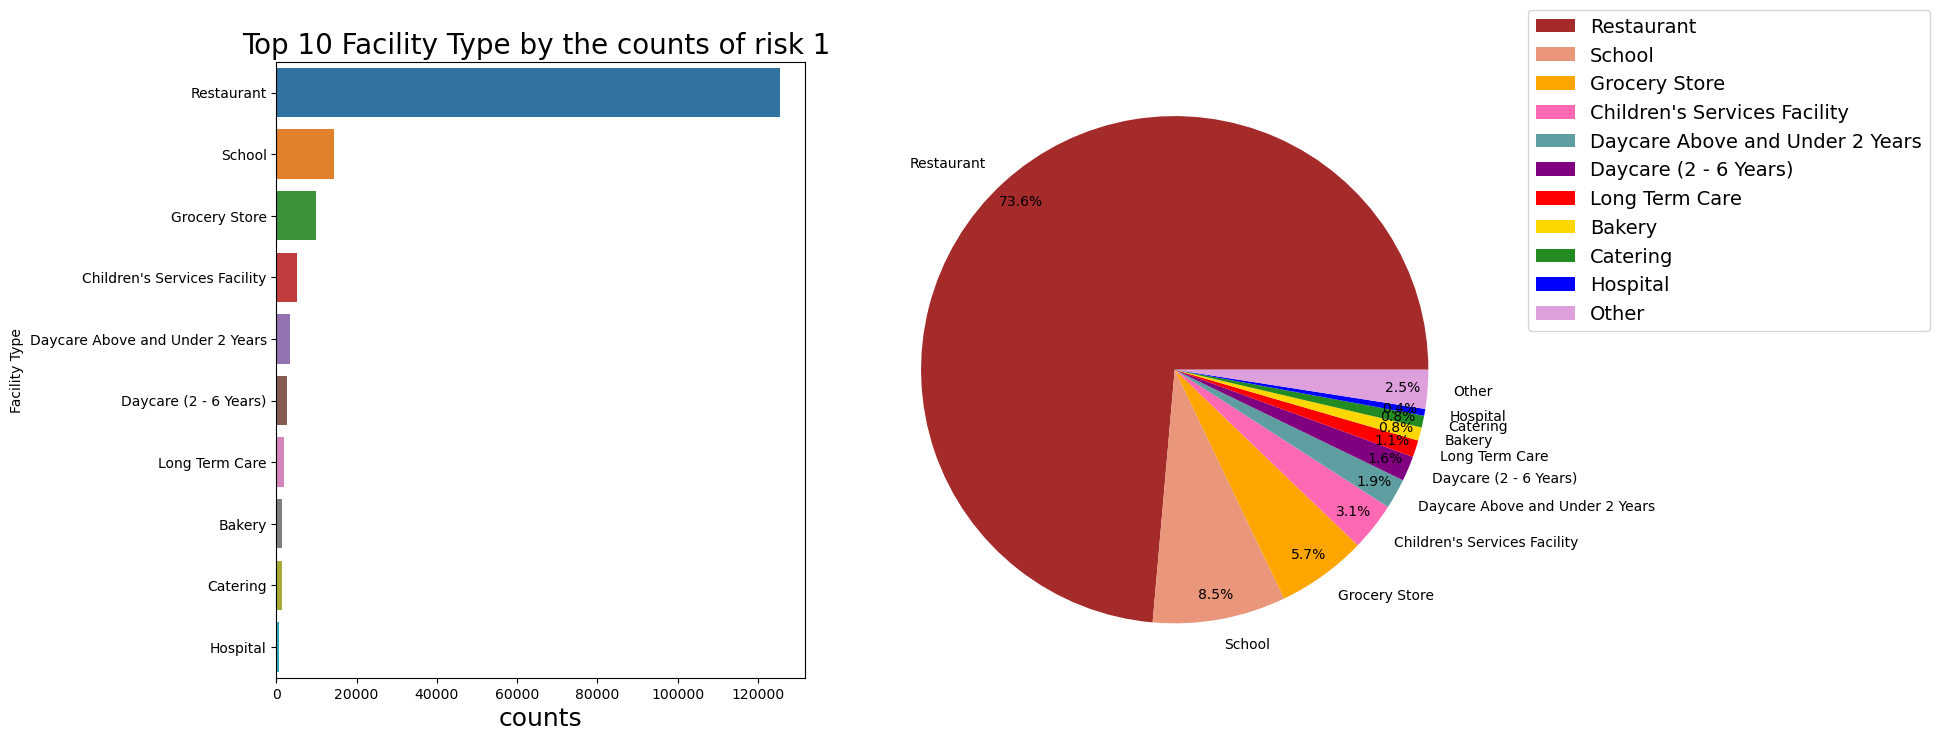

In [256]:
data_risk1=df[df.Risk=='Risk 1 (High)']
fig,ax=plt.subplots(1,2,figsize=(15,8))
sns.barplot(x=data_risk1['Facility Type'].value_counts()[:10],y=data_risk1['Facility Type'].value_counts()[:10].index,ax=ax[0])
ax[0].set_title("Top 10 Facility Type by the counts of risk 1 ",size=20)
ax[0].set_xlabel('counts',size=18)


count=data_risk1.groupby(['Facility Type'])['Inspection ID'].agg('count').sort_values(ascending=False)
groups=list(data_risk1.groupby(['Facility Type'])['Inspection ID'].agg('count').sort_values(ascending=False).index[:10])
counts=list(count[:10])
counts.append(count.agg(sum)-count[:10].agg('sum'))
groups.append('Other')
type_dict=pd.DataFrame({"group":groups,"counts":counts})
clr1=('brown','darksalmon','orange','hotpink','cadetblue','purple','red','gold','forestgreen','blue','plum')
type_dict.plot(kind='pie', y='counts', labels=groups,colors=clr1,autopct='%1.1f%%', pctdistance=0.9, radius=1.2,ax=ax[1])
ax[1].set_ylabel('')
ax[1].legend(loc=0, ncol=1, fontsize=14,bbox_to_anchor=(1.15,1.2))

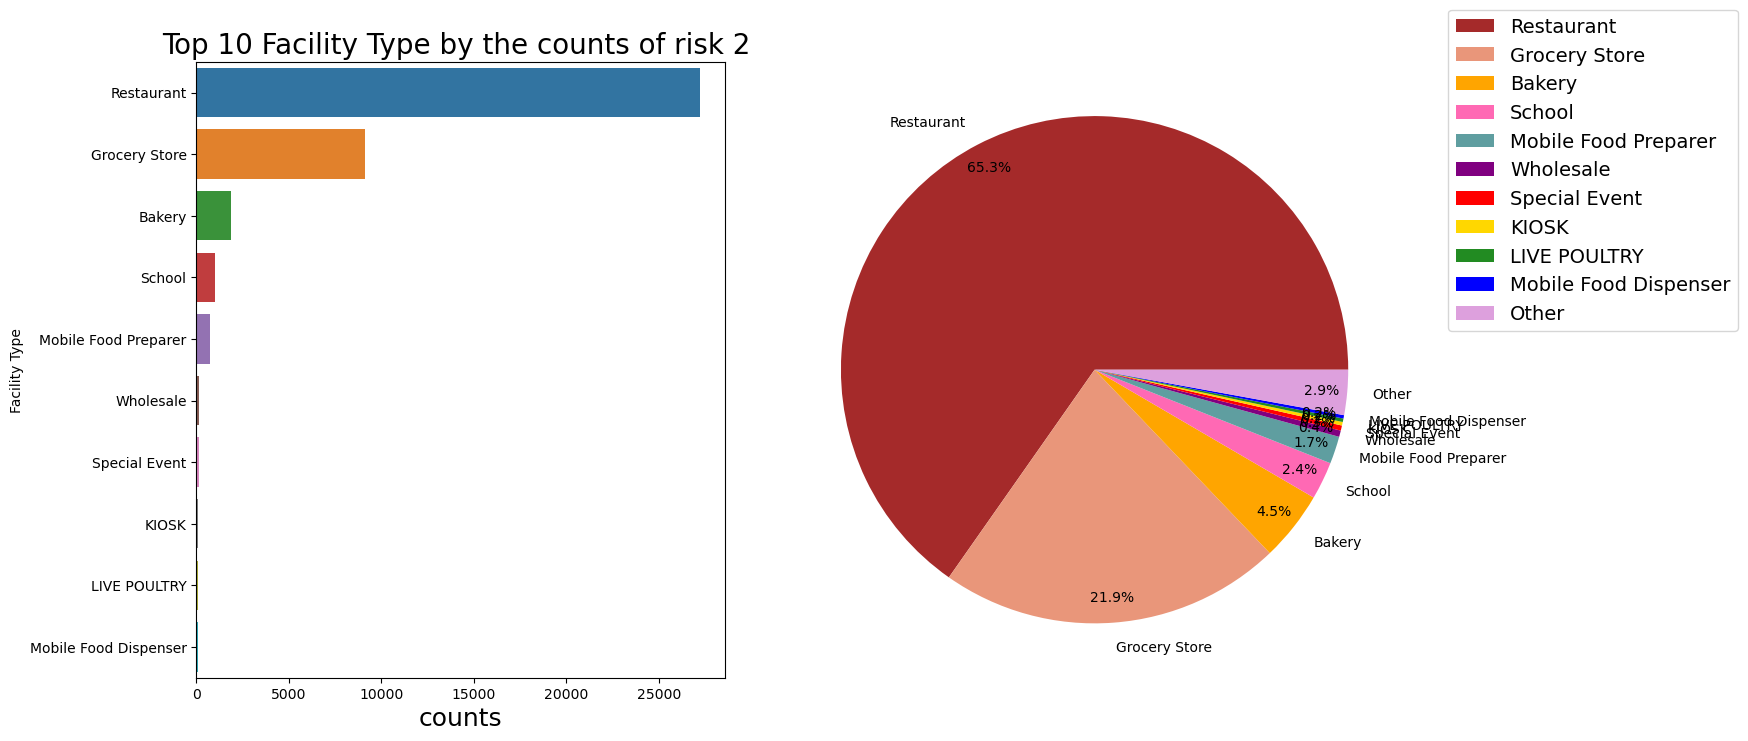

In [257]:
data_risk2=df[df.Risk=='Risk 2 (Medium)']

fig,ax=plt.subplots(1,2,figsize=(15,8))
sns.barplot(x=data_risk2['Facility Type'].value_counts()[:10],y=data_risk2['Facility Type'].value_counts()[:10].index,ax=ax[0])
ax[0].set_title("Top 10 Facility Type by the counts of risk 2 ",size=20)
ax[0].set_xlabel('counts',size=18)


count=data_risk2.groupby(['Facility Type'])['Inspection ID'].agg('count').sort_values(ascending=False)
groups=list(data_risk2.groupby(['Facility Type'])['Inspection ID'].agg('count').sort_values(ascending=False).index[:10])
counts=list(count[:10])
counts.append(count.agg(sum)-count[:10].agg('sum'))
groups.append('Other')
type_dict=pd.DataFrame({"group":groups,"counts":counts})
clr1=('brown','darksalmon','orange','hotpink','cadetblue','purple','red','gold','forestgreen','blue','plum')
type_dict.plot(kind='pie', y='counts', labels=groups,colors=clr1,autopct='%1.1f%%', pctdistance=0.9, radius=1.2,ax=ax[1])
ax[1].set_ylabel('')
ax[1].legend(loc=0, ncol=1, fontsize=14,bbox_to_anchor=(1.15,1.2))

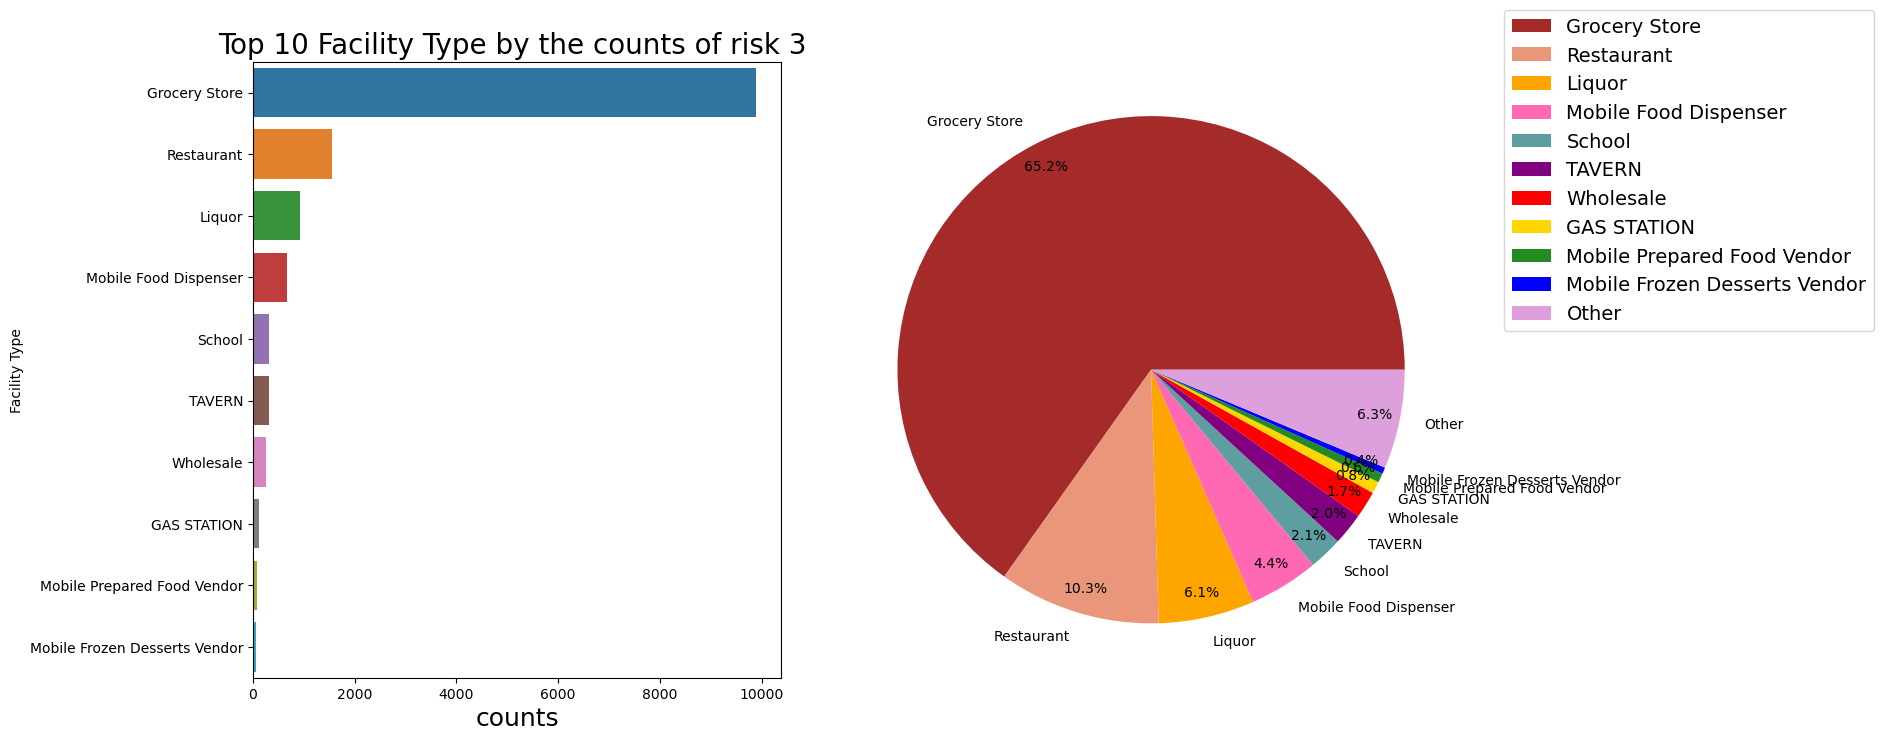

In [258]:
data_risk3=df[df.Risk=='Risk 3 (Low)']

fig,ax=plt.subplots(1,2,figsize=(15,8))
sns.barplot(x=data_risk3['Facility Type'].value_counts()[:10],y=data_risk3['Facility Type'].value_counts()[:10].index,ax=ax[0])
ax[0].set_title("Top 10 Facility Type by the counts of risk 3 ",size=20)
ax[0].set_xlabel('counts',size=18)


count=data_risk3.groupby(['Facility Type'])['Inspection ID'].agg('count').sort_values(ascending=False)
groups=list(data_risk3.groupby(['Facility Type'])['Inspection ID'].agg('count').sort_values(ascending=False).index[:10])
counts=list(count[:10])
counts.append(count.agg(sum)-count[:10].agg('sum'))
groups.append('Other')
type_dict=pd.DataFrame({"group":groups,"counts":counts})
clr1=('brown','darksalmon','orange','hotpink','cadetblue','purple','red','gold','forestgreen','blue','plum')
type_dict.plot(kind='pie', y='counts', labels=groups,colors=clr1,autopct='%1.1f%%', pctdistance=0.9, radius=1.2,ax=ax[1])
ax[1].set_ylabel('')
ax[1].legend(loc=0, ncol=1, fontsize=14,bbox_to_anchor=(1.15,1.2))

In [259]:
x = df['Results'].value_counts().index.values.astype('str')
y = df['Results'].value_counts().values
pct = [("%.2f"%(v*100))+"%"for v in (y/len(df))]


trace1 = go.Bar(x=x, y=y, text=pct)
layout = dict(title= 'Inspectation Results Count',
              yaxis = dict(title='Count'),
              xaxis = dict(title='Results'))
fig=dict(data=[trace1], layout=layout)
iplot(fig)

In [260]:
df.groupby(['Risk', 'Results']).size().reset_index(name="Frequency")


,Risk,Results,Frequency
0,All,Fail,5
1,Risk 1 (High),Fail,37418
2,Risk 1 (High),Pass,102270
3,Risk 1 (High),Pass w/ Conditions,31020
4,Risk 2 (Medium),Fail,9523
5,Risk 2 (Medium),Pass,24770
6,Risk 2 (Medium),Pass w/ Conditions,7515
7,Risk 3 (Low),Fail,4602
8,Risk 3 (Low),Pass,8960
9,Risk 3 (Low),Pass w/ Conditions,1785


<Axes: xlabel='Results', ylabel='Risk'>

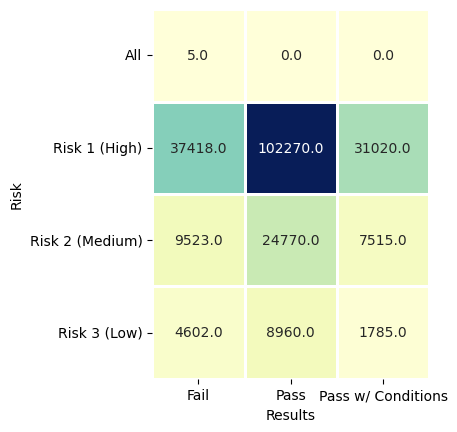

In [261]:
sns.heatmap(pd.crosstab([df.Risk], [df.Results]),
            cmap="YlGnBu", annot=True, fmt=".1f", linewidths=1.0, square=1, cbar=False)

Text(0, 0.5, 'LATITUDE')

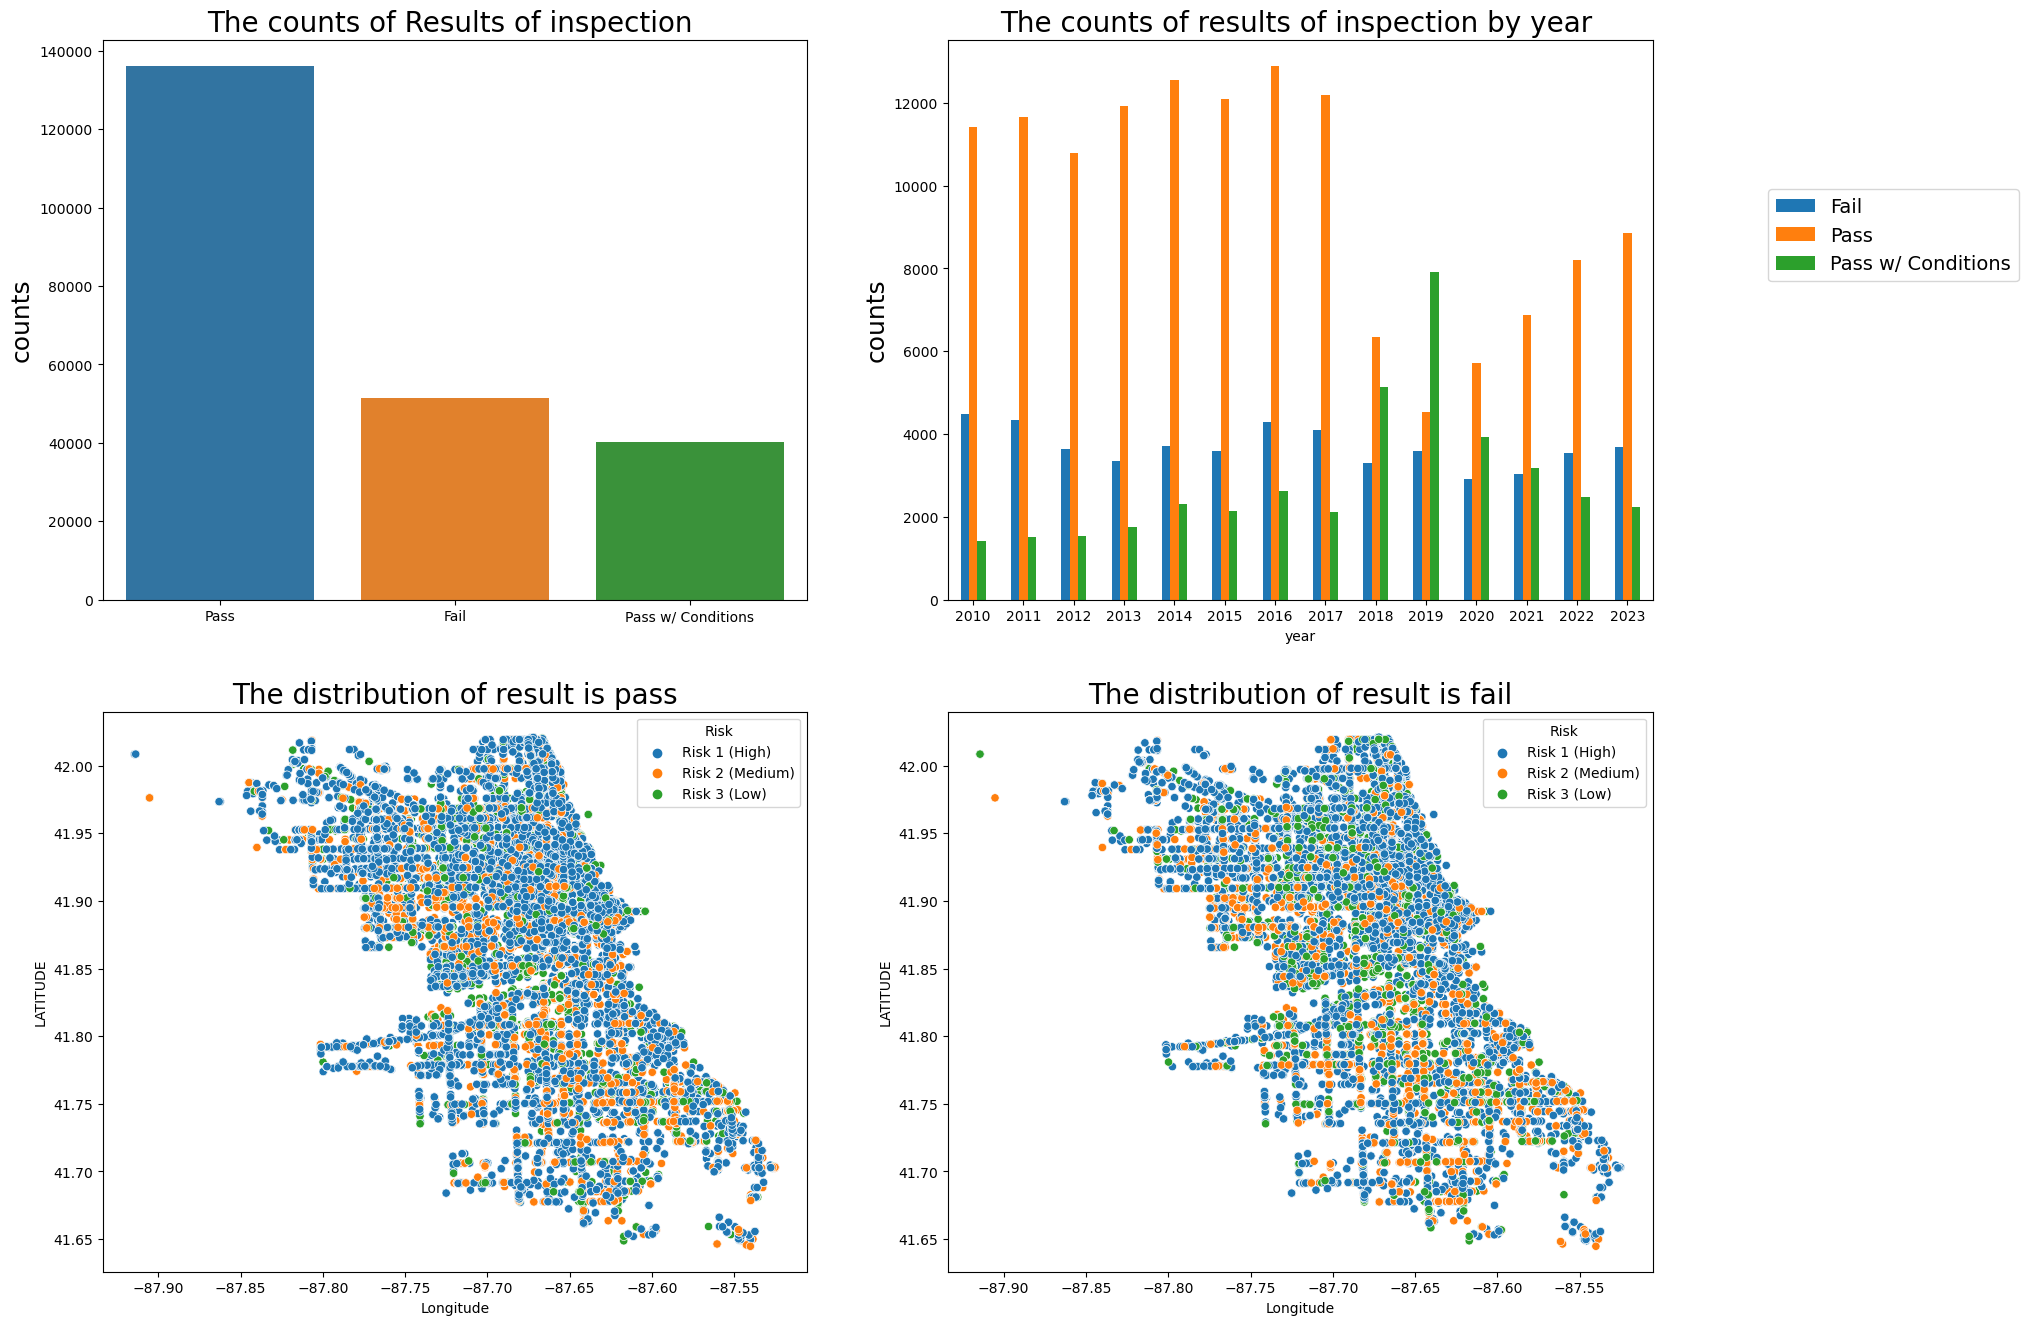

In [262]:
fig,ax=plt.subplots(2,2,figsize=(20,16))
x=df.Results.value_counts().index
y=df.Results.value_counts()
sns.barplot(x=x,y=y,ax=ax[0,0])
ax[0,0].set_title("The counts of Results of inspection ",size=20)
ax[0,0].set_ylabel('counts',size=18)
ax[0,0].set_xlabel('')

df.groupby(['Results','year'])['Inspection ID'].agg('count').unstack('Results').plot(kind='bar',ax=ax[0,1])
ax[0,1].tick_params(axis='x',labelrotation=360)
ax[0,1].legend(loc=0, ncol=1, fontsize=14,bbox_to_anchor=(1.15,0.75))
ax[0,1].set_title("The counts of results of inspection by year ",size=20)
ax[0,1].set_ylabel('counts',size=18)

sns.scatterplot(x='Longitude',y='Latitude',hue='Risk' ,hue_order=['Risk 1 (High)','Risk 2 (Medium)','Risk 3 (Low)'],data=df[df.Results=='Pass'], ax=ax[1,0])
ax[1,0].set_title("The distribution of result is pass",size=20)
ax[1,0].set_xlabel('Longitude')
ax[1,0].set_ylabel('LATITUDE')

sns.scatterplot(x='Longitude',y='Latitude',hue='Risk',hue_order=['Risk 1 (High)','Risk 2 (Medium)','Risk 3 (Low)'] ,data=df[df.Results=='Fail'], ax=ax[1,1])
ax[1,1].set_title("The distribution of result is fail",size=20)
ax[1,1].set_xlabel('Longitude')
ax[1,1].set_ylabel('LATITUDE')

In [263]:
df['Restaurant'] = (df['Facility Type'].values == 'Restaurant').astype('int')



<Axes: xlabel='Risk', ylabel='Restaurant'>

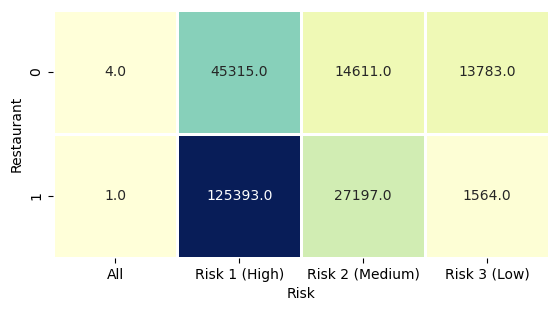

In [264]:
sns.heatmap(pd.crosstab([df.Restaurant], [df.Risk]),
            cmap="YlGnBu", annot=True, fmt=".1f", linewidths=1.0, square=1, cbar=False)

<Axes: xlabel='Results', ylabel='Restaurant'>

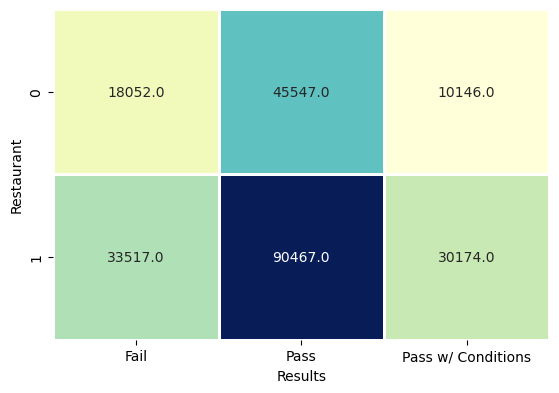

In [265]:
sns.heatmap(pd.crosstab([df.Restaurant], [df.Results]),
            cmap="YlGnBu", annot=True, fmt=".1f", linewidths=1.0, square=1, cbar=False)

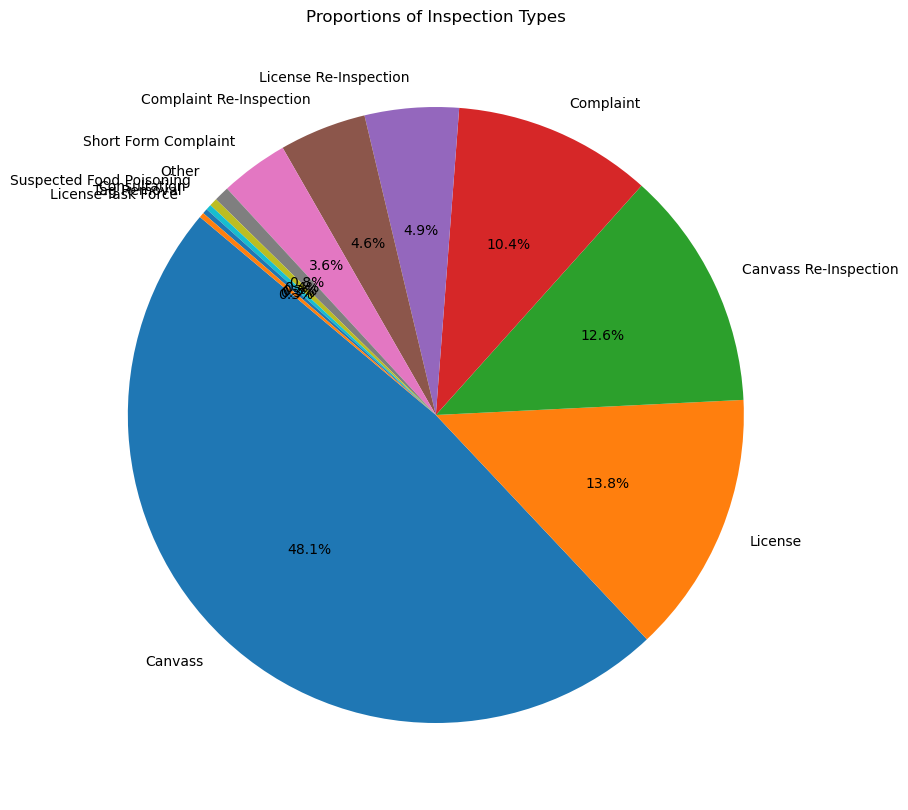

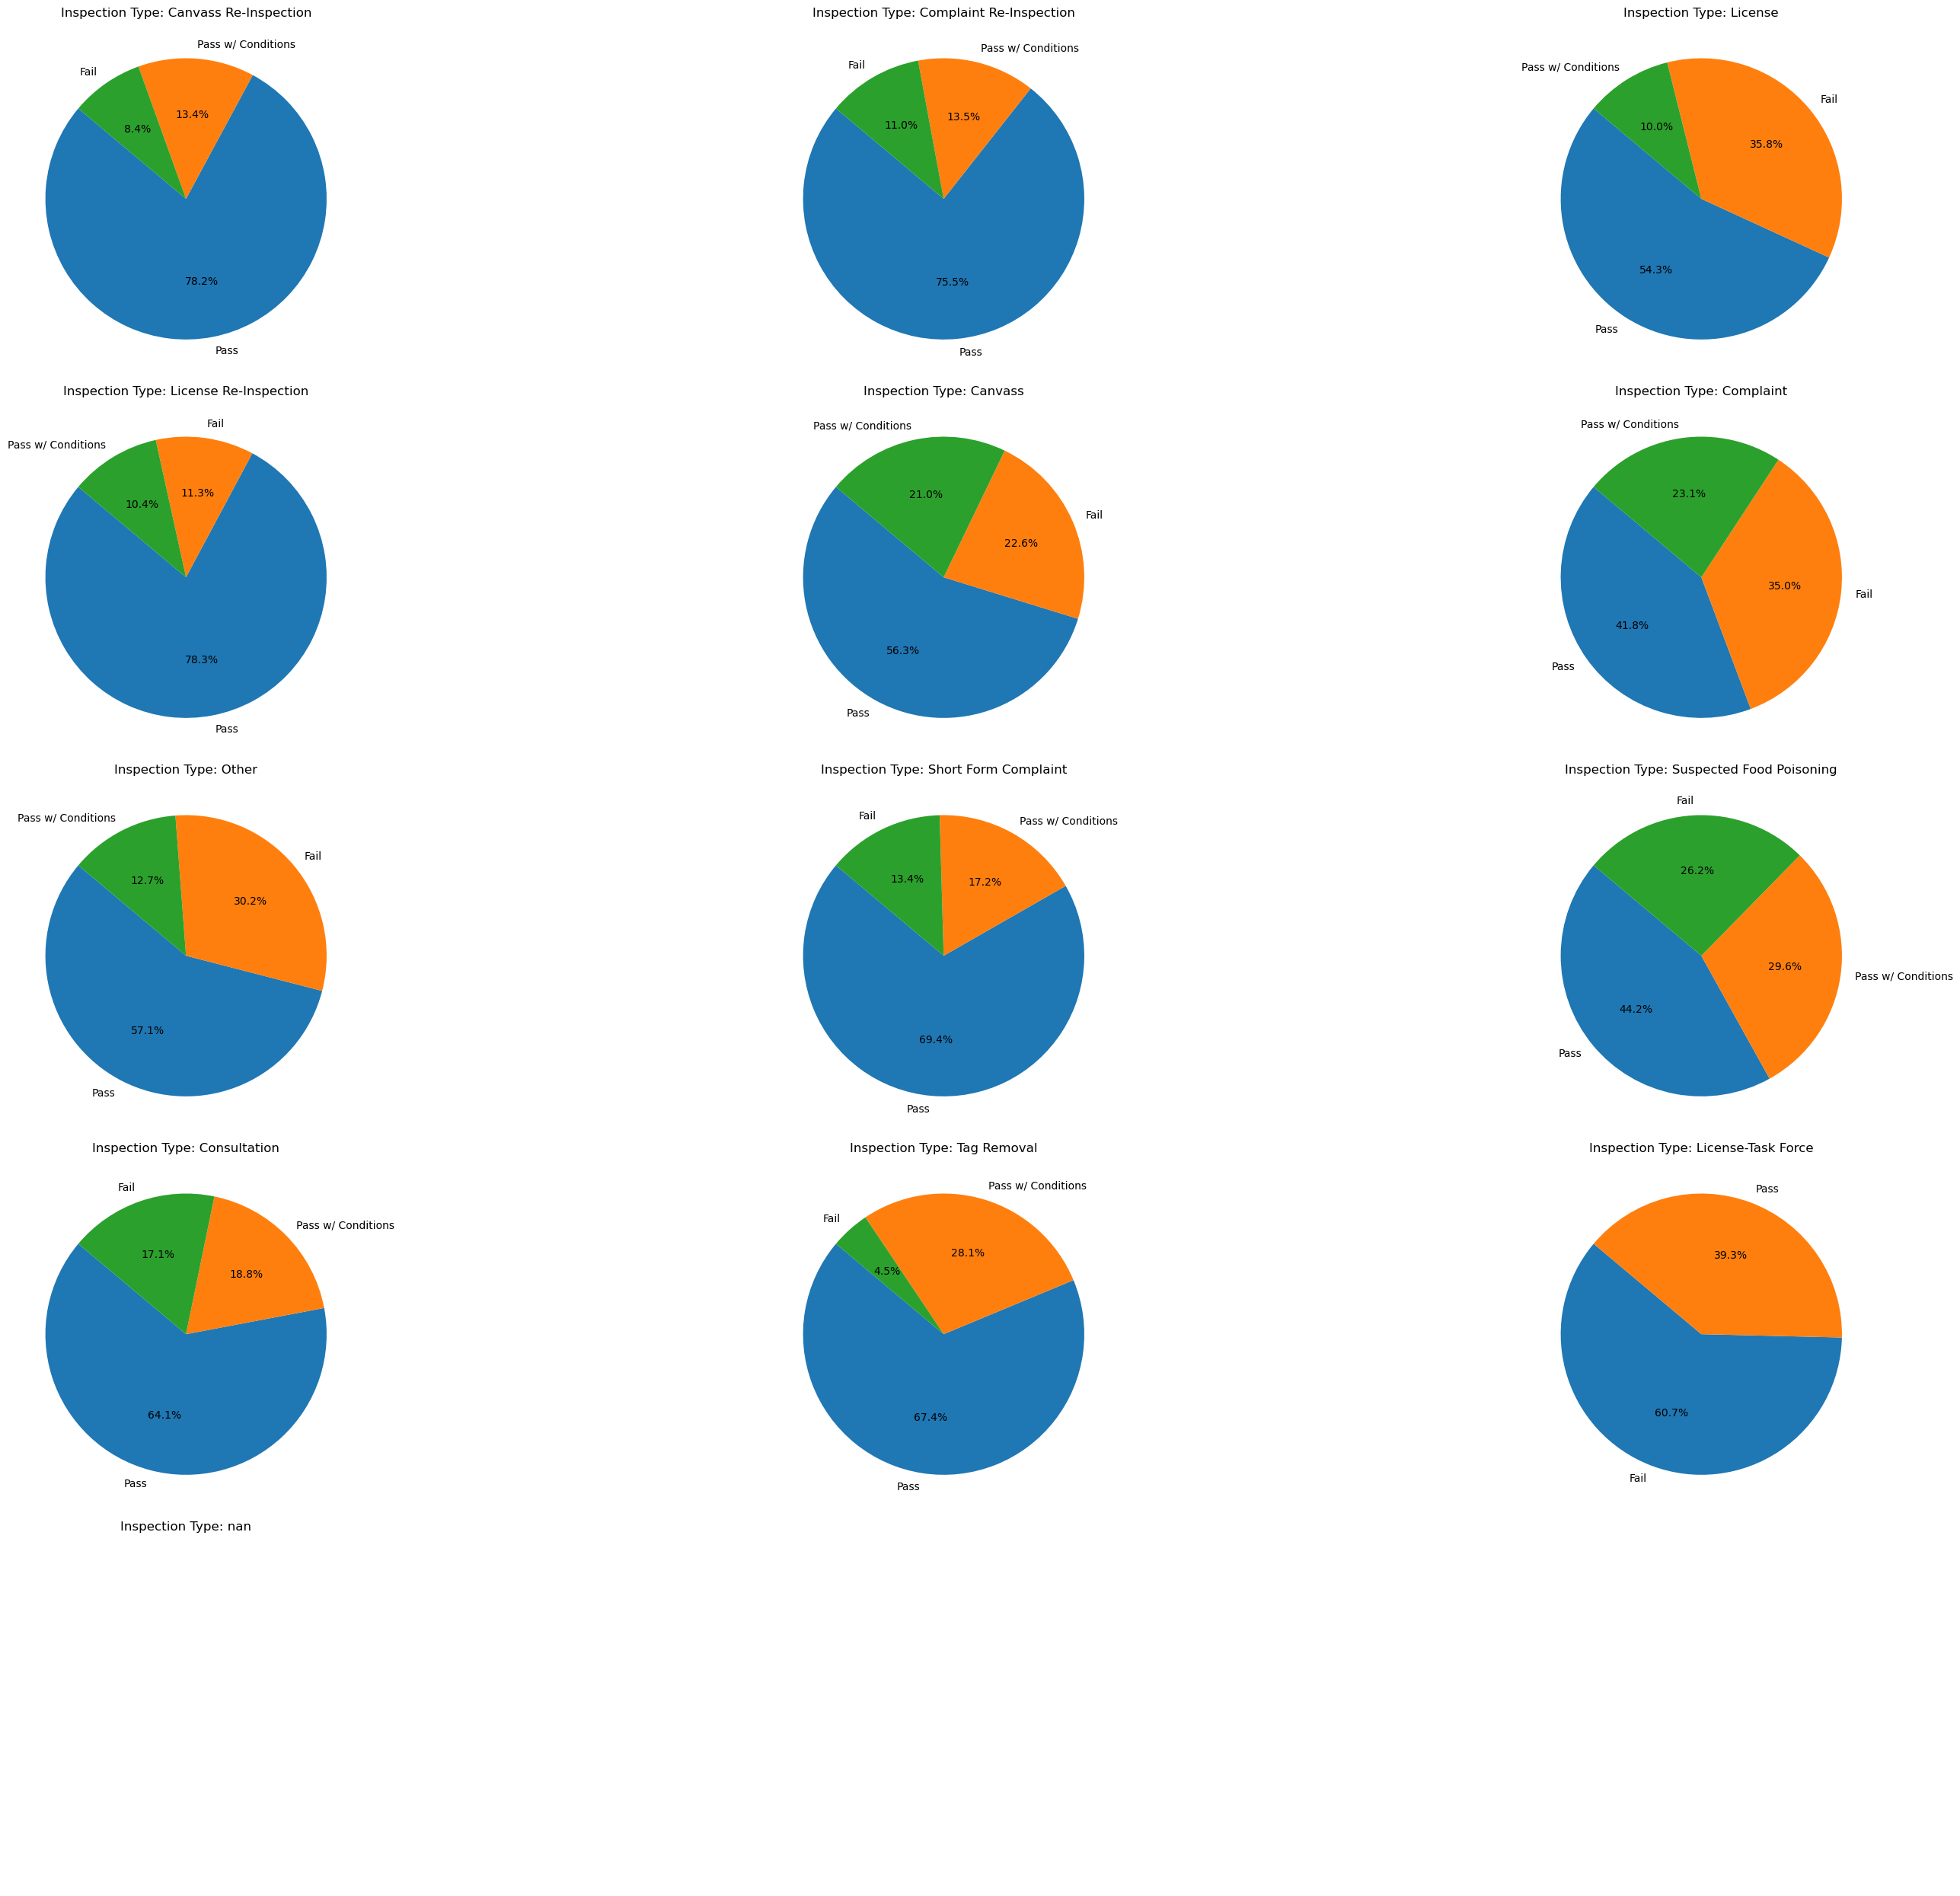

In [266]:
inspection_type_counts = df['Inspection Type'].value_counts()
rare_types = inspection_type_counts[inspection_type_counts <= 500].index
df['Inspection Type'] = df['Inspection Type'].apply(lambda x: 'Other' if x in rare_types else x)
inspection_type_counts_updated = df['Inspection Type'].value_counts()

plt.figure(figsize=(10, 10))
plt.pie(inspection_type_counts_updated, labels=inspection_type_counts_updated.index, autopct='%1.1f%%', startangle=140)
plt.title('Proportions of Inspection Types')
plt.show()

unique_inspection_types = df['Inspection Type'].unique()

n_types = len(unique_inspection_types)
n_cols = 3
n_rows = -(-n_types // n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(10 * n_cols, 5 * n_rows))
axes = axes.flatten()

for i, inspection_type in enumerate(unique_inspection_types):
    type_data = df[df['Inspection Type'] == inspection_type]
    
    result_counts = type_data['Results'].value_counts(normalize=True)
    
    axes[i].pie(result_counts, labels=result_counts.index, autopct='%1.1f%%', startangle=140)
    axes[i].set_title(f'Inspection Type: {inspection_type}')

if n_types % n_cols != 0:
    for j in range(i + 1, n_rows * n_cols):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [267]:
df['Violations'] = df['Violations'].astype(str)
df[df["Violations"] == "nan"]

,Inspection ID,DBA Name,AKA Name,license,Facility Type,Risk,Address,City,State,Zip,...,Inspection Type,Results,Violations,Latitude,Longitude,Location,year,month,day,Restaurant
0,2587265,AREPA GEORGE,AREPA GEORGE,2522680.0,Restaurant,Risk 1 (High),1552 N KEDZIE AVE,CHICAGO,IL,60651.0,...,Canvass Re-Inspection,Pass,nan,41.909898,-87.707145,"(41.909897849174, -87.70714515263228)",2023,12,20,1
1,2587168,MARGARITA'S PIZZERIA,MARGARITA'S PIZZERIA,48819.0,Restaurant,Risk 1 (High),2705 - 2707 E 79TH ST,CHICAGO,IL,60649.0,...,Complaint Re-Inspection,Pass,nan,41.751723,-87.558700,"(41.75172337100072, -87.55869963532268)",2023,12,19,1
2,2587169,BRISTOL FOOD & LIQUOR,BRISTOL FOOD & LIQUOR,2943885.0,Grocery Store,Risk 3 (Low),5201-5207 W BELMONT AVE,CHICAGO,IL,60641.0,...,License,Pass,nan,41.938589,-87.756810,"(41.93858918622007, -87.75681004516909)",2023,12,19,0
3,2587086,FARMAIR'S MARKET,FARMER'S MARKET (T5 / M7),2944236.0,Grocery Store,Risk 3 (Low),11601 W TOUHY AVE,CHICAGO,IL,60666.0,...,License,Pass,nan,42.008536,-87.914428,"(42.008536400868735, -87.91442843927047)",2023,12,18,0
9,2587001,MAXWELLS TRADING,MAXWELLS TRADING,2938839.0,Restaurant,Risk 1 (High),1516 W CARROLL ST,CHICAGO,IL,60607.0,...,License Re-Inspection,Pass,nan,41.887524,-87.665099,"(41.88752359761481, -87.66509874730654)",2023,12,15,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265130,88285,rendezvous bistro,NaN,2021807.0,Restaurant,Risk 1 (High),2656 W Lawrence AVE,CHICAGO,IL,60625.0,...,License,Fail,nan,41.968663,-87.696105,"(41.96866318490796, -87.69610498322785)",2010,3,5,1
265133,176717,TITOS RESTAURANT,TITOS RESTAURANT,1992224.0,Restaurant,Risk 1 (High),1555 N CICERO AVE,CHICAGO,IL,60651.0,...,Other,Fail,nan,41.909422,-87.745968,"(41.90942176715542, -87.74596790287065)",2010,3,12,1
265136,150209,YSABEL'S FILIPINO CUISINE,YSABEL'S GRILL ASIAN CUISINE,2013419.0,Restaurant,Risk 1 (High),4908 W Irving Park RD,CHICAGO,IL,60641.0,...,License Re-Inspection,Pass,nan,41.953485,-87.750248,"(41.953485015058135, -87.750248227467)",2010,1,12,1
265141,154300,ANMOL RESTAURANT,ANMOL RESTAURANT,2021367.0,Restaurant,Risk 1 (High),2858 W DEVON AVE,CHICAGO,IL,60659.0,...,License Re-Inspection,Pass,nan,41.997628,-87.702018,"(41.99762830086828, -87.70201840060844)",2010,3,5,1


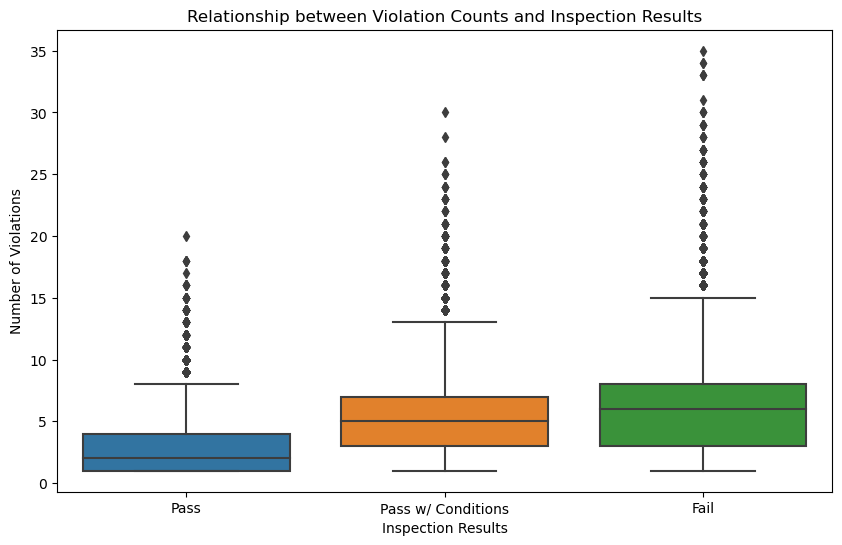

In [268]:
df['Violation Count'] = df['Violations'].apply(lambda x: len(str(x).split('|')))

# Visualize the relationship between Violation Count and Results
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Results'], y=df['Violation Count'])
plt.title('Relationship between Violation Counts and Inspection Results')
plt.xlabel('Inspection Results')
plt.ylabel('Number of Violations')
plt.show()

In [269]:
df['Violations'] = df['Violations'].astype(str)
df = df[df.Violations != "nan"]
df.shape

(191065, 22)

In [270]:
from sklearn.preprocessing import LabelEncoder 

le = LabelEncoder() 
df['DBA Name'] = le.fit_transform(df['DBA Name'])
df['Facility Type'] = df['Facility Type'].astype(str)
df['Facility Type'] = le.fit_transform(df['Facility Type'])
df['Address'] = le.fit_transform(df['Address'])
df['Zip'] = le.fit_transform(df['Zip'])
df['Results'] = (df['Results'].values == 'Fail').astype('int')
df['Violations'] = le.fit_transform(df["Violations"])
df['Inspection Type'] = le.fit_transform(df["Inspection Type"])
df['Risk'] = le.fit_transform(df['Risk'])

In [271]:
df = df.drop(['Inspection ID', 'AKA Name', 'City', 'State', 'Inspection Date', 'Location'], axis = 1)

In [272]:
x = df['Results'].value_counts().index
y = df['Results'].value_counts().values

trace2 = go.Bar(
     x=x ,
     y=y,
     marker=dict(
         color=y,
         colorscale = 'Viridis',
         reversescale = True
     ),
     name="Imbalance",    
 )
layout = dict(
     title="Data imbalance - Results",
     #width = 900, height = 500,
     xaxis=go.layout.XAxis(
     automargin=True),
     yaxis=dict(
         showgrid=False,
         showline=False,
         showticklabels=True,
 #         domain=[0, 0.85],
     ), 
)
fig1 = go.Figure(data=[trace2], layout=layout)
iplot(fig1)

In [273]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


# Decision Tree
X = df.drop('Results', axis=1)
y = df['Results']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

predictions = tree_model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy}")

Model Accuracy: 0.8477669225401256


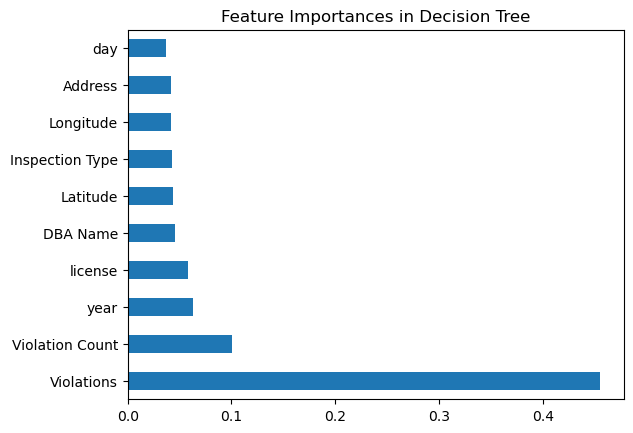

[0.04524359 0.05799193 0.01022802 0.00572039 0.04177035 0.02614083
 0.04264237 0.45522075 0.04369674 0.04193205 0.06322815 0.02463884
 0.03663163 0.00402635 0.10088803]
Index(['DBA Name', 'license', 'Facility Type', 'Risk', 'Address', 'Zip',
       'Inspection Type', 'Violations', 'Latitude', 'Longitude', 'year',
       'month', 'day', 'Restaurant', 'Violation Count'],
      dtype='object')


In [274]:
feature_importances = pd.Series(tree_model.feature_importances_, index=X.columns)
feature_importances.nlargest(10).plot(kind='barh')
plt.title('Feature Importances in Decision Tree')
plt.show()
print(tree_model.feature_importances_)
print(X.columns)